In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import numpy as np
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
import torch.optim as optim
from PIL import Image
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torchvision.models as models

In [ ]:
# Định nghĩa các phép biến đổi cho tập huấn luyện và tập validation
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Thay đổi kích thước ảnh về 224x224 để phù hợp với ResNet-50
    transforms.RandomHorizontalFlip(),  # lật ảnh theo chiều ngang
    transforms.RandomRotation(10),  # xoay ảnh ngẫu nhiên tối đa 10 độ
    transforms.ToTensor(),  # Chuyển ảnh sang dạng tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Giá trị trung bình của ImageNet
                         std=[0.229, 0.224, 0.225])   # Độ lệch chuẩn của ImageNet
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Thay đổi kích thước ảnh
    transforms.ToTensor(),  # Chuyển ảnh sang tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Chuẩn hóa theo ImageNet
                         std=[0.229, 0.224, 0.225])
])

# Tải dataset
dataset = ImageFolder(root='/kaggle/input/dataset2/data_Train', transform=train_transforms)

# Chia dữ liệu thành tập train và validation (ví dụ: 80% train, 20% validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

# Áp dụng các phép biến đổi dành cho validation cho tập validation
val_dataset.dataset.transform = val_transforms

# Tạo DataLoader để đọc dữ liệu theo batch
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)

# Kiểm tra số lượng ảnh của mỗi lớp (tùy chọn, dùng để kiểm tra dataset)
class_counts = {}
for class_name in dataset.classes:
    class_counts[class_name] = len([x for x, y in dataset.samples if dataset.classes[y] == class_name])
print("Số lượng ảnh của mỗi lớp:", class_counts)

Số lượng ảnh của mỗi lớp: {'airplane': 6619, 'car': 6395, 'cat': 6216, 'dog': 5165, 'flower': 3669, 'fruit': 5747, 'motorbike': 3815, 'person': 6334}


In [ ]:
# Khởi tạo mô hình ResNet50 (không sử dụng pretrained mặc định)
model = models.resnet50(pretrained=False)  # Chúng ta sẽ nạp trọng số (weights) thủ công

# Tải file trọng số đã lưu với tham số weights_only=True để tránh cảnh báo
state_dict = torch.load('/kaggle/input/model_dauvao/pytorch/default/1/resnet50-0676ba61.pth', weights_only=True)

# Nạp các trọng số đã tải vào mô hình
model.load_state_dict(state_dict)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


<All keys matched successfully>

In [ ]:
# Chọn thiết bị để huấn luyện: GPU nếu có, nếu không thì dùng CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Đóng băng (freeze) các lớp đã được huấn luyện trước của mô hình
# Điều này giúp giữ nguyên các trọng số đã học từ trước trong giai đoạn huấn luyện ban đầu
for param in model.parameters():
    param.requires_grad = False

# Thay đổi lớp fully connected cuối cùng để phù hợp với bài toán phân loại 8 lớp
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 8)  # 8 lớp: airplane, car, cat, dog, flower, fruit, motorbike, person

# Mở khóa (unfreeze) lớp cuối cùng để lớp này có thể được huấn luyện
for param in model.fc.parameters():
    param.requires_grad = True

# Đảm bảo mô hình được đưa lên đúng thiết bị (GPU hoặc CPU)
model = model.to(device)

In [ ]:
# Định nghĩa hàm mất mát (loss function) và thuật toán tối ưu (optimizer)
criterion = nn.CrossEntropyLoss()  # Hàm loss dùng cho bài toán phân loại nhiều lớp
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  # Chỉ tối ưu lớp fully connected cuối

# Vòng lặp huấn luyện (training loop)
num_epochs = 15  # Số epoch huấn luyện (có thể điều chỉnh tùy nhu cầu)

for epoch in range(num_epochs):

    # ===== Giai đoạn huấn luyện (Training phase) =====
    model.train()  # Đặt mô hình ở chế độ train
    running_loss = 0.0

    for inputs, labels in train_loader:
        # Chuyển dữ liệu sang thiết bị (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # Xóa gradient của bước trước

        outputs = model(inputs)  # Lan truyền tiến (forward pass)
        loss = criterion(outputs, labels)  # Tính giá trị loss

        loss.backward()  # Lan truyền ngược (backpropagation)
        optimizer.step()  # Cập nhật trọng số

        running_loss += loss.item()  # Cộng dồn giá trị loss

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {running_loss/len(train_loader):.4f}")

    # ===== Giai đoạn đánh giá (Validation phase) =====
    model.eval()  # Đặt mô hình ở chế độ đánh giá
    correct = 0
    total = 0
    val_loss = 0.0

    # Không tính gradient để tiết kiệm bộ nhớ và tăng tốc
    with torch.no_grad():
        for inputs, labels in val_loader:

            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)  # Dự đoán

            loss = criterion(outputs, labels)  # Tính loss cho validation
            val_loss += loss.item()

            # Lấy lớp có xác suất cao nhất
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)  # Tổng số mẫu
            correct += (predicted == labels).sum().item()  # Số dự đoán đúng

    print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Accuracy: {100 * correct / total:.2f}%")

In [ ]:
# Mở khóa (unfreeze) toàn bộ các lớp của mô hình
for param in model.parameters():
    param.requires_grad = True

# Sử dụng learning rate nhỏ hơn cho giai đoạn fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
torch.save(model.state_dict(), '/kaggle/working/natural_resnet50_model2.pth')

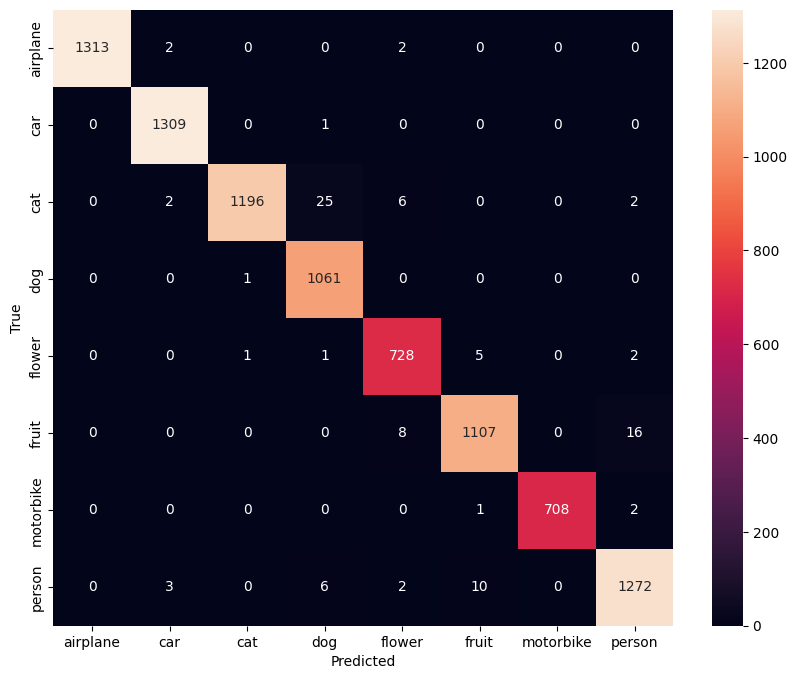

In [ ]:
# Thu thập các nhãn dự đoán và nhãn thực tế
all_preds = []
all_labels = []

model.eval()  # Đặt mô hình ở chế độ đánh giá

# Không tính gradient để tiết kiệm bộ nhớ và tăng tốc độ
with torch.no_grad():
    for inputs, labels in val_loader:
        # Chuyển dữ liệu sang thiết bị (GPU hoặc CPU)
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)  # Dự đoán từ mô hình

        # Lấy lớp có xác suất cao nhất
        _, preds = torch.max(outputs, 1)

        # Lưu kết quả dự đoán và nhãn thật
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Tính ma trận nhầm lẫn (confusion matrix)
cm = confusion_matrix(all_labels, all_preds)

# Vẽ confusion matrix dưới dạng heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=dataset.classes, yticklabels=dataset.classes)

# Nhãn trục
plt.xlabel('Predicted')  # Nhãn dự đoán
plt.ylabel('True')       # Nhãn thực tế

plt.show()

In [ ]:
# Tải và tiền xử lý một ảnh đơn lẻ
image_path = '/kaggle/input/dataset2/data_GK_new/dog/n02085620_10074.jpg'
image = Image.open(image_path)  # Mở ảnh từ đường dẫn

# Áp dụng các phép biến đổi dùng cho tập validation và thêm chiều batch
image = val_transforms(image).unsqueeze(0)  # Thêm batch dimension (1, C, H, W)

# Chuyển ảnh sang thiết bị (GPU hoặc CPU)
image = image.to(device)

# Thực hiện dự đoán
model.eval()  # Đặt mô hình ở chế độ đánh giá

# Không tính gradient để tiết kiệm bộ nhớ
with torch.no_grad():
    output = model(image)  # Dự đoán từ mô hình

    # Lấy lớp có xác suất cao nhất
    _, predicted = torch.max(output, 1)

    # Chuyển index dự đoán sang tên lớp
    predicted_class = dataset.classes[predicted.item()]

    # In ra kết quả dự đoán
    print(f"Lớp được dự đoán: {predicted_class}")

Lớp được dự đoán: dog


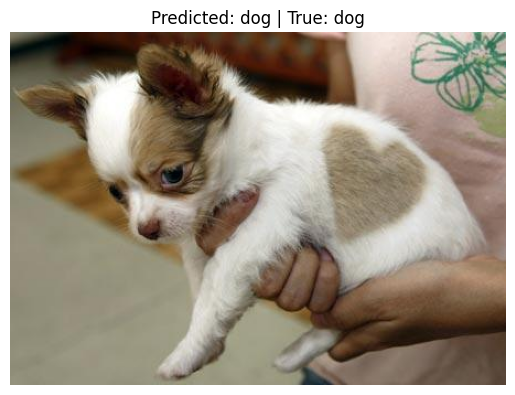

Predicted class: dog
True class: dog


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

image_path = '/kaggle/input/dataset2/data_GK_new/dog/n02085620_1346.jpg' # Đường dẫn ảnh
true_label = image_path.split('/')[-2] # Lấy nhãn thật từ thư mục cha
original_image = Image.open(image_path) # Đọc ảnh gốc để hiển thị

# Tiền xử lý ảnh
image = val_transforms(original_image).unsqueeze(0)  # thêm batch dimension
image = image.to(device)

# Dự đoán
model.eval()
with torch.no_grad():
    output = model(image)
    _, predicted = torch.max(output, 1)
    predicted_class = dataset.classes[predicted.item()]

# Hiển thị ảnh
plt.imshow(original_image)
plt.axis("off")

# Hiển thị dự đoán và nhãn thật
plt.title(f"Predicted: {predicted_class} | True: {true_label}")

plt.show()

# In ra console
print("Predicted class:", predicted_class)
print("True class:", true_label)